`Импорт данных`

In [63]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics import mean_squared_error, r2_score, max_error, mean_absolute_percentage_error, mean_absolute_error

from my_package.data_structurs import *
from my_package.utils import *
from my_package.approximation import *

In [2]:
csv_obj = CSVFilesObject('./././data/serias_from_images/csv_format/sup/', ',', False)

In [3]:
def get_mapping_from_dir(csv_object:CSVFilesObject):
    loader = MappingLoadersFromCSV(csv_object)
    
    all_mappings = {}

    for label, mapping in loader:
        all_mappings[label] = mapping

    return all_mappings

In [4]:
loader = MappingLoadersFromCSV(csv_obj)

### Визуализация начальных данных

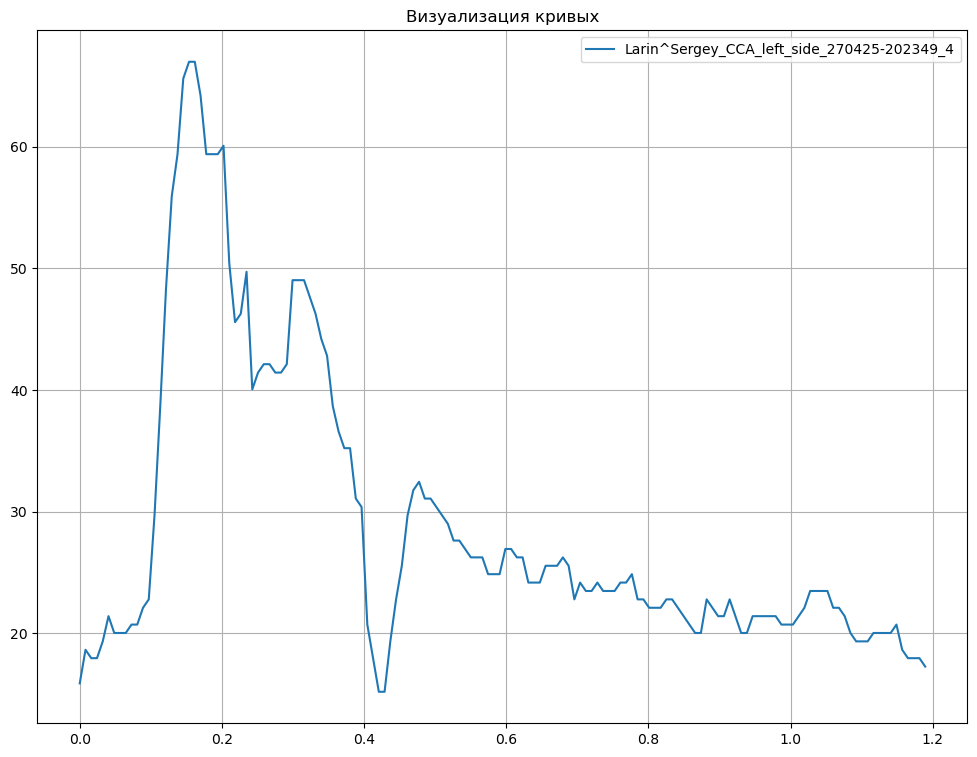

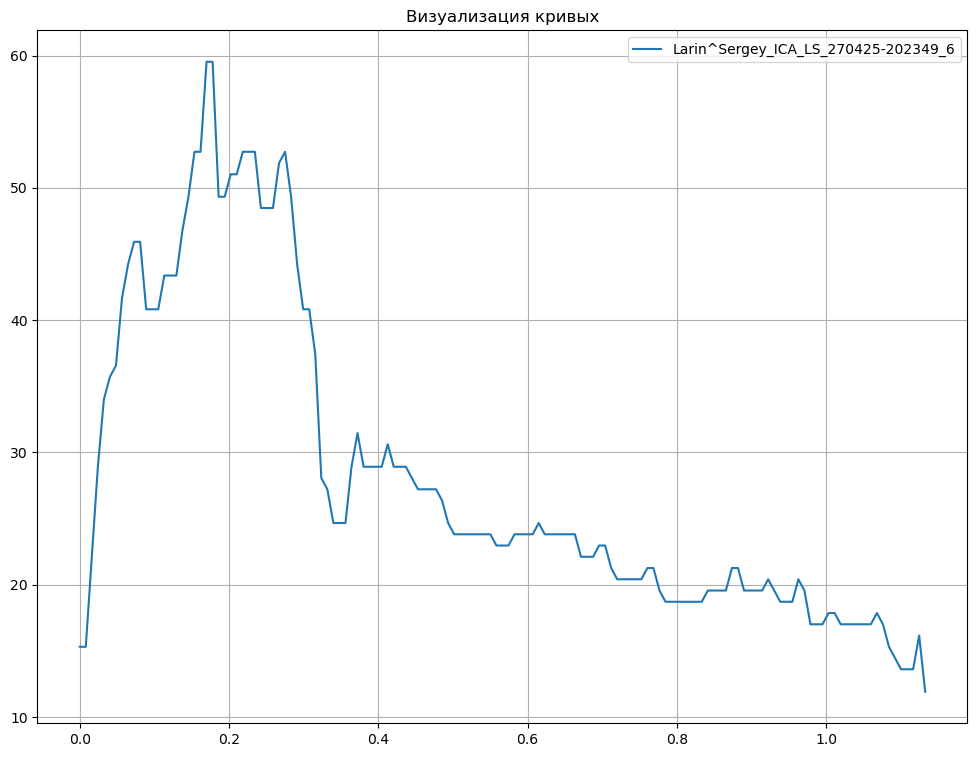

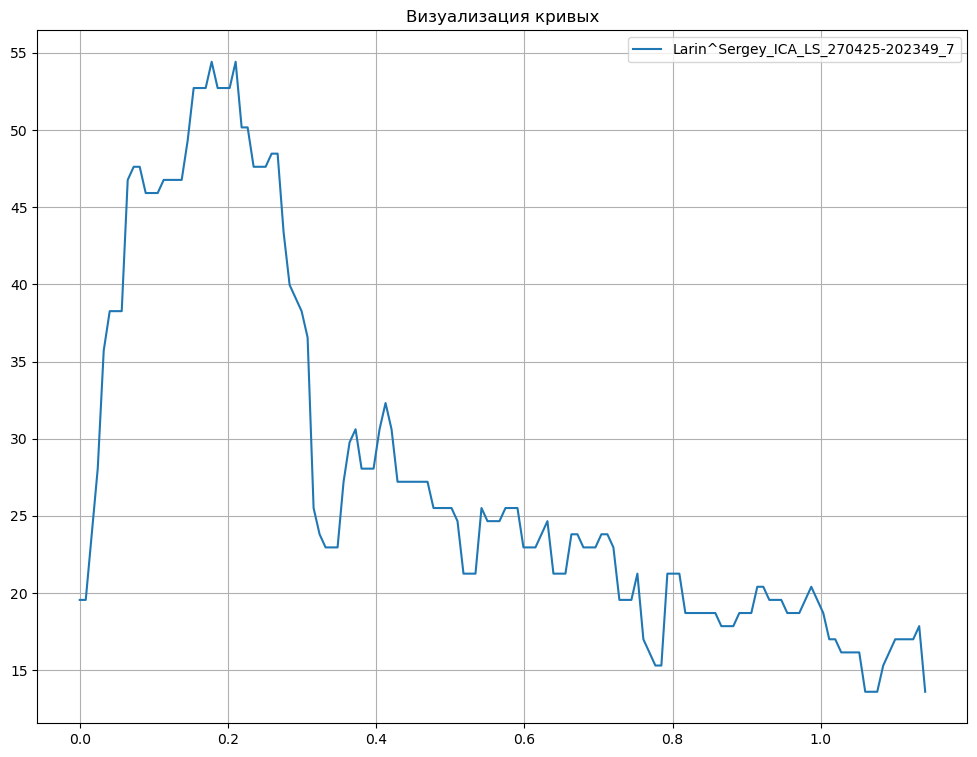

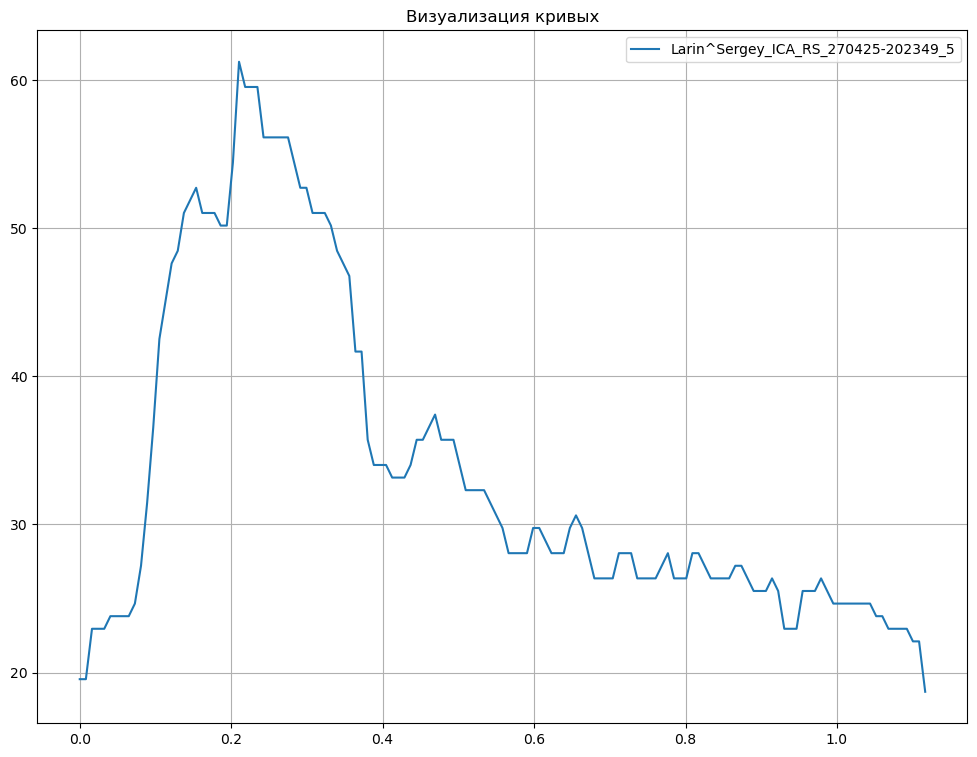

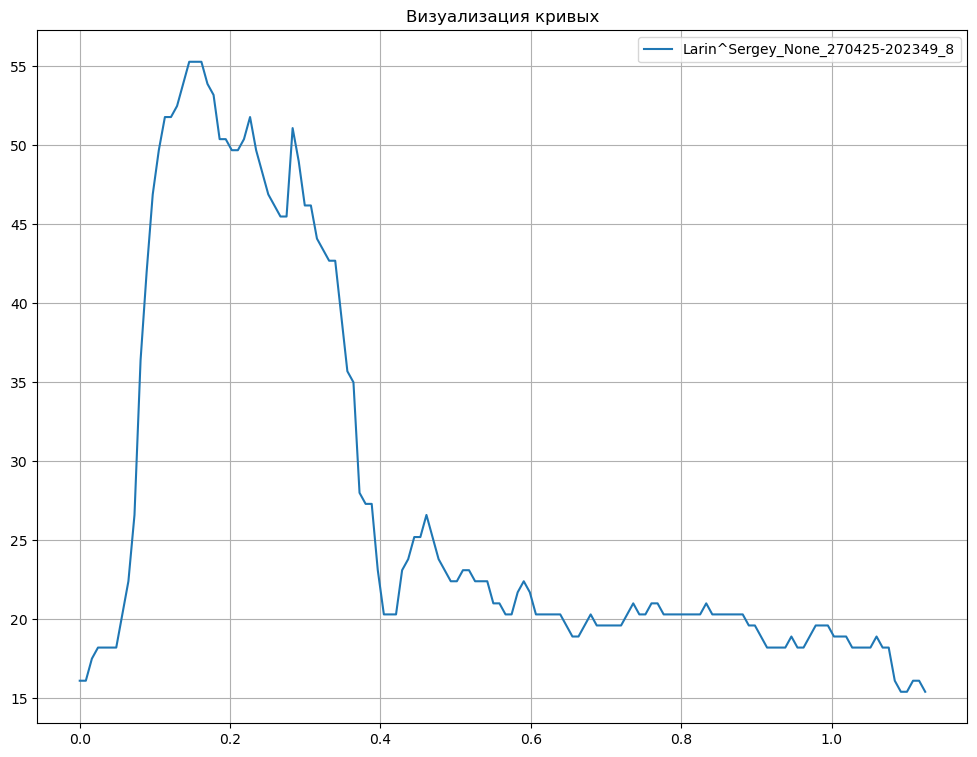

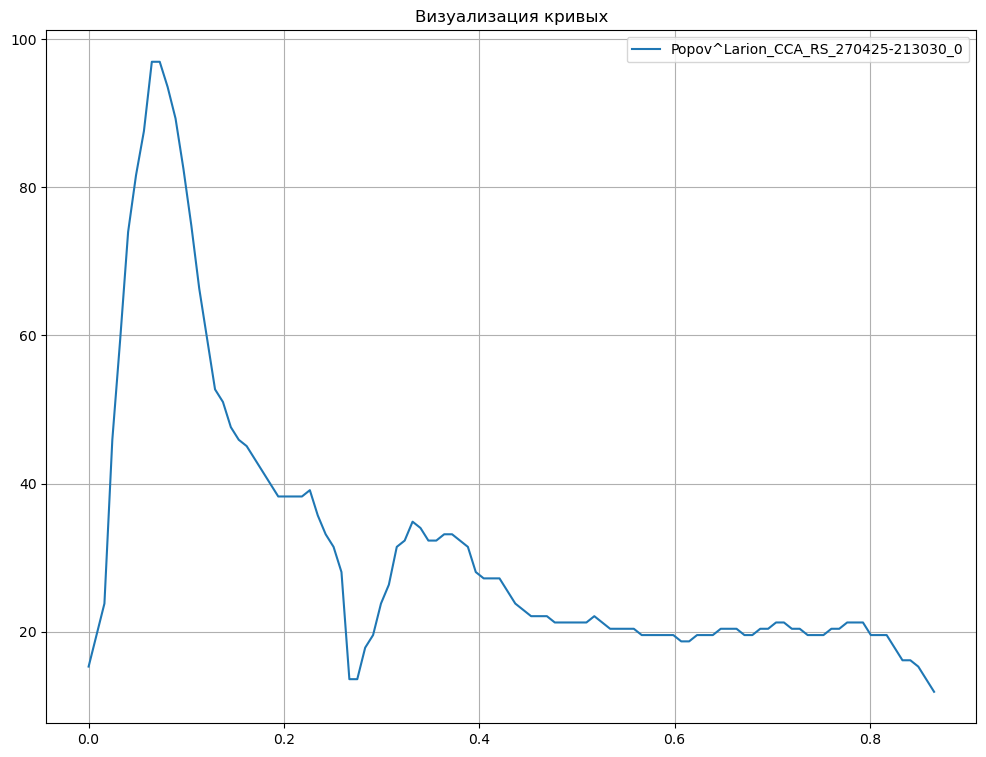

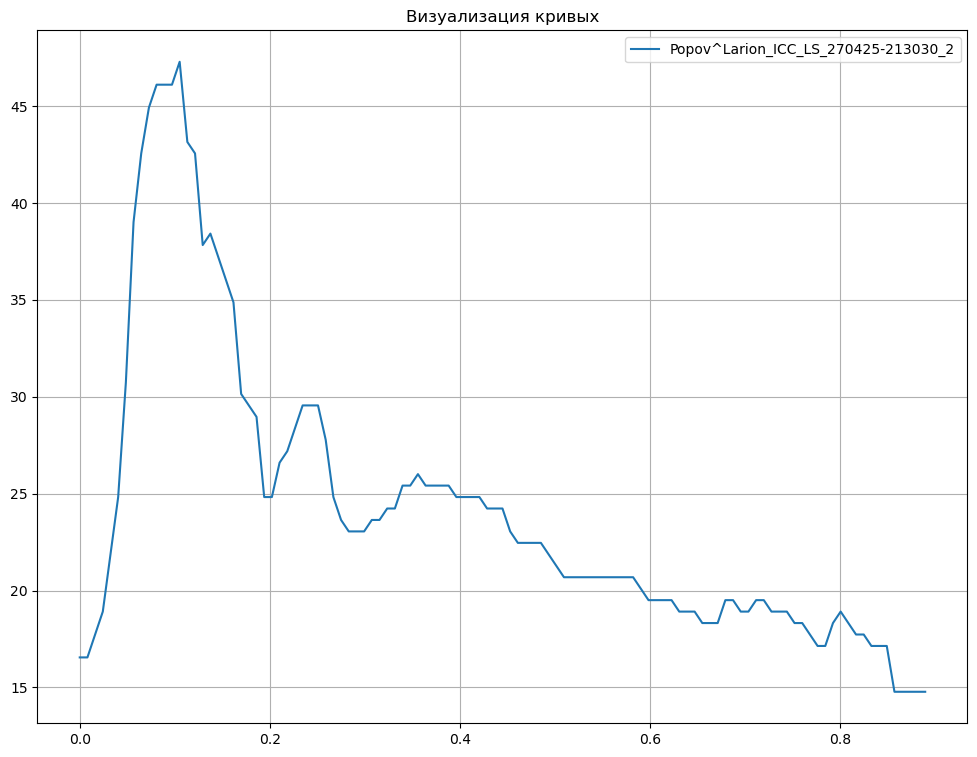

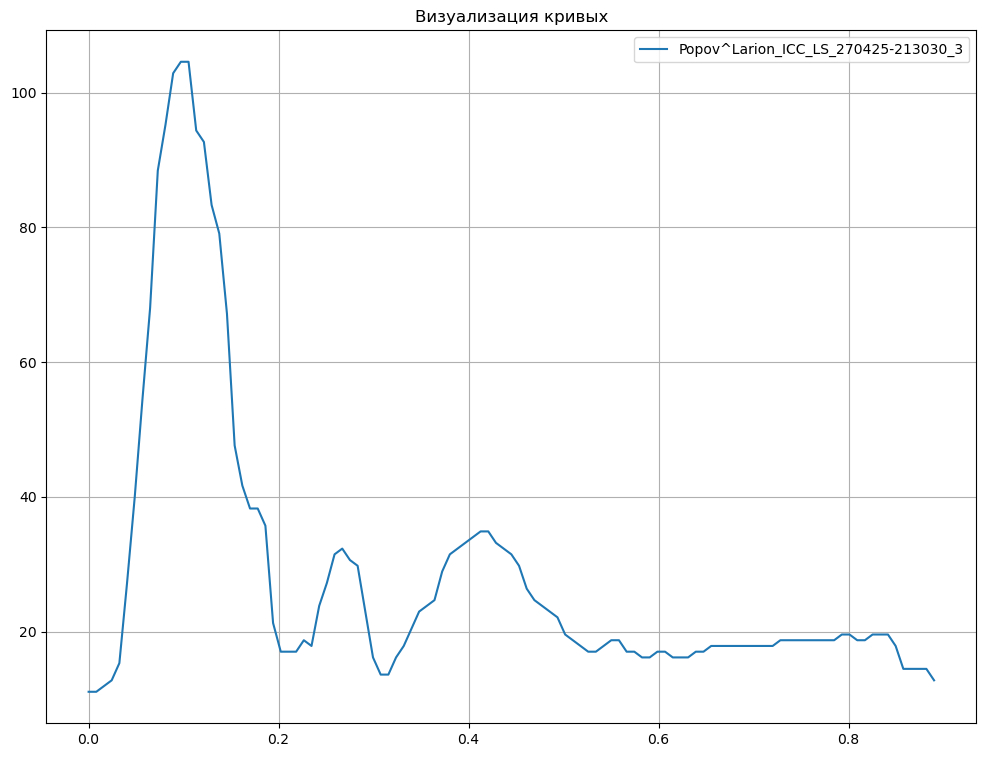

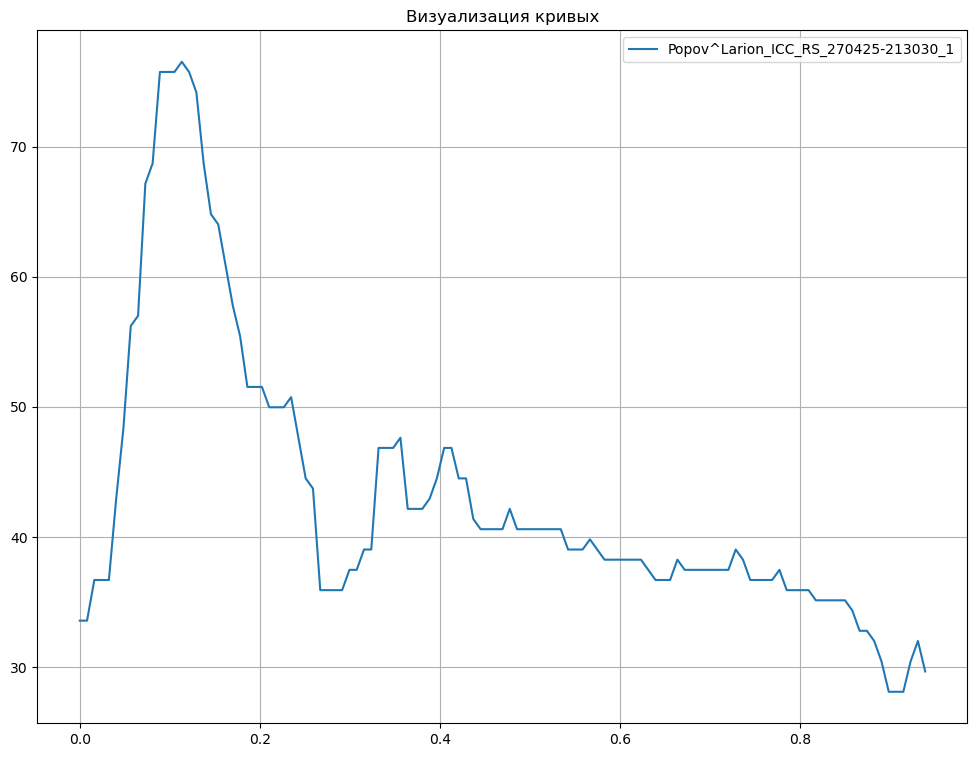

In [5]:
visualizator = VisualizationPlots(
    (12, 9),
    'Визуализация кривых',
    True
)

for label, mapping in loader:
    visualizator.create_plot([mapping.get_x()], [mapping.get_y()], [label])

### Предварительная аппроксимация скользящим средним

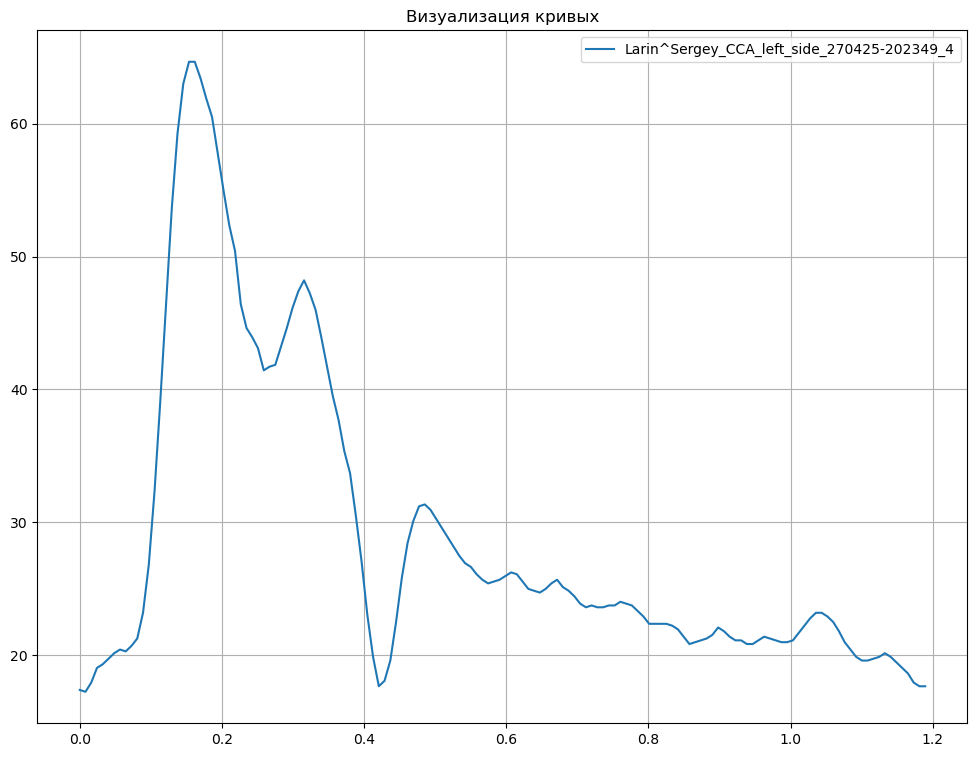

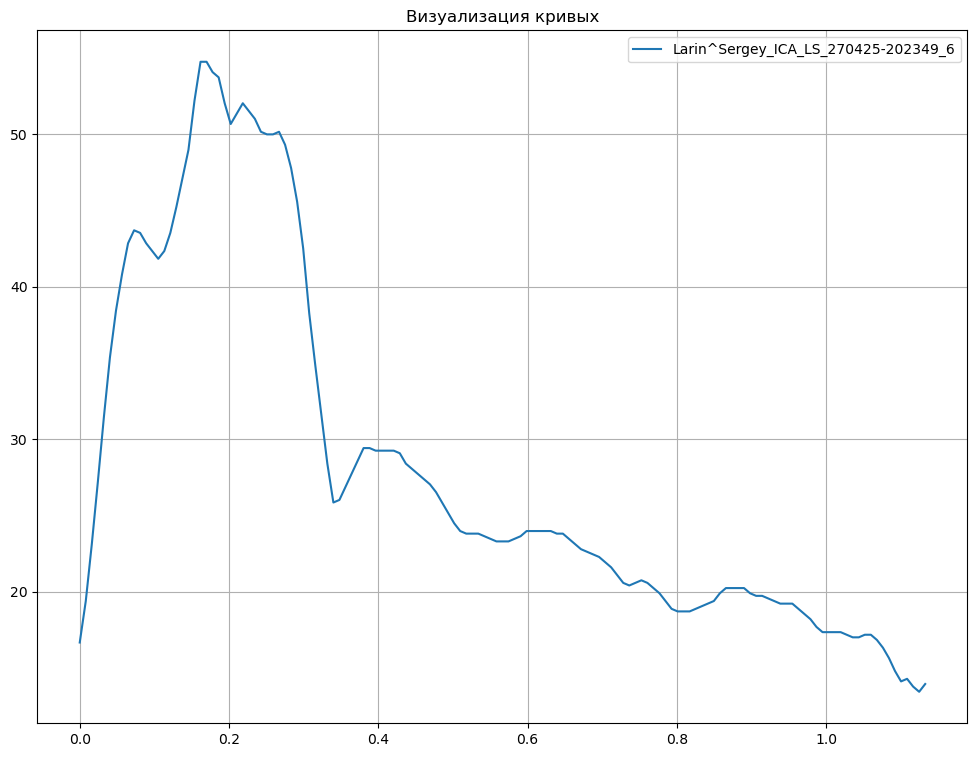

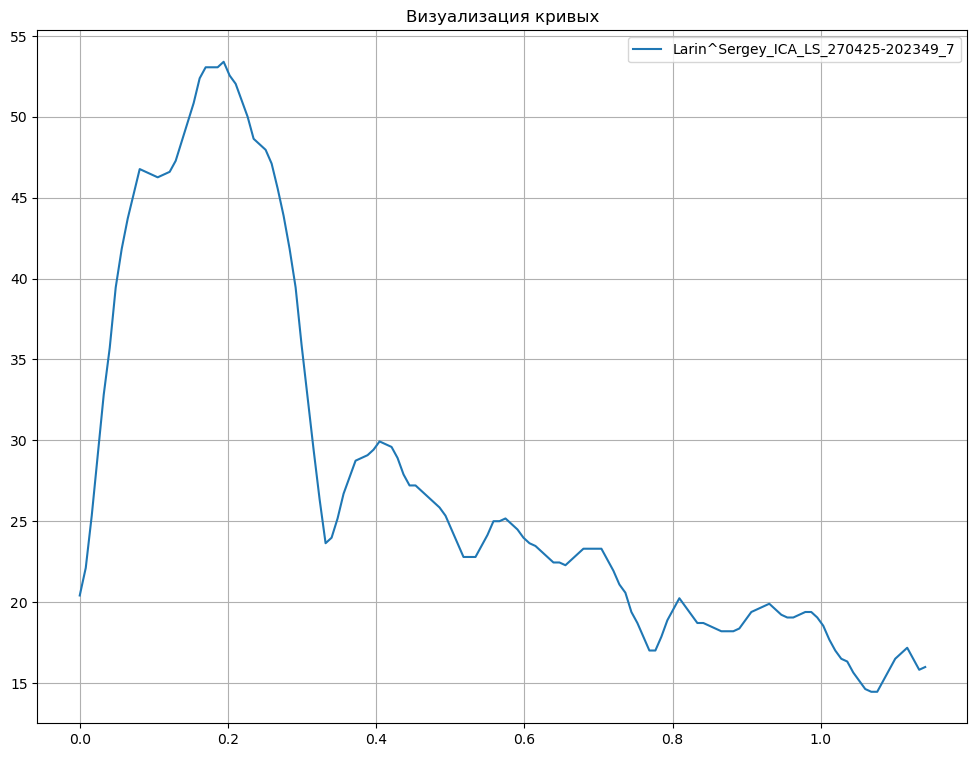

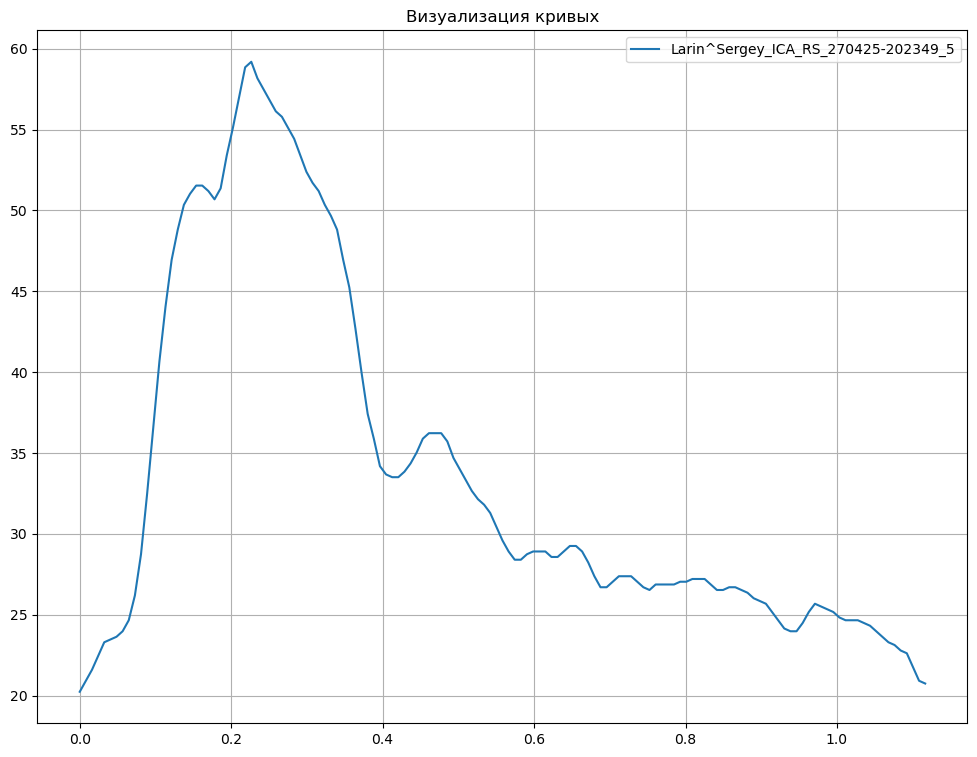

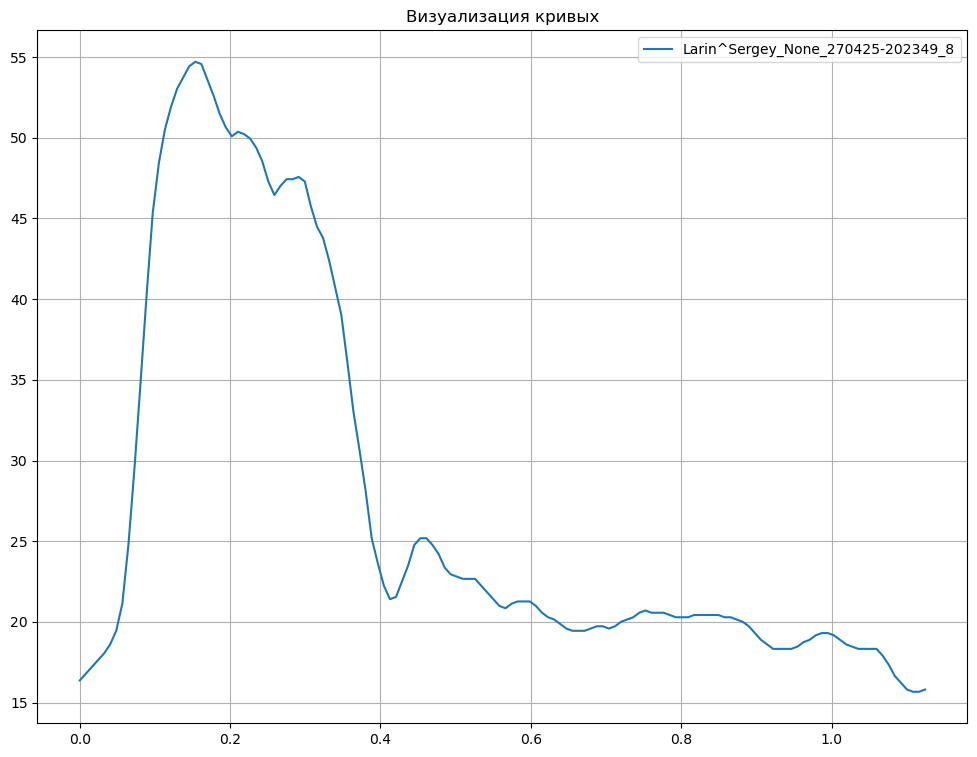

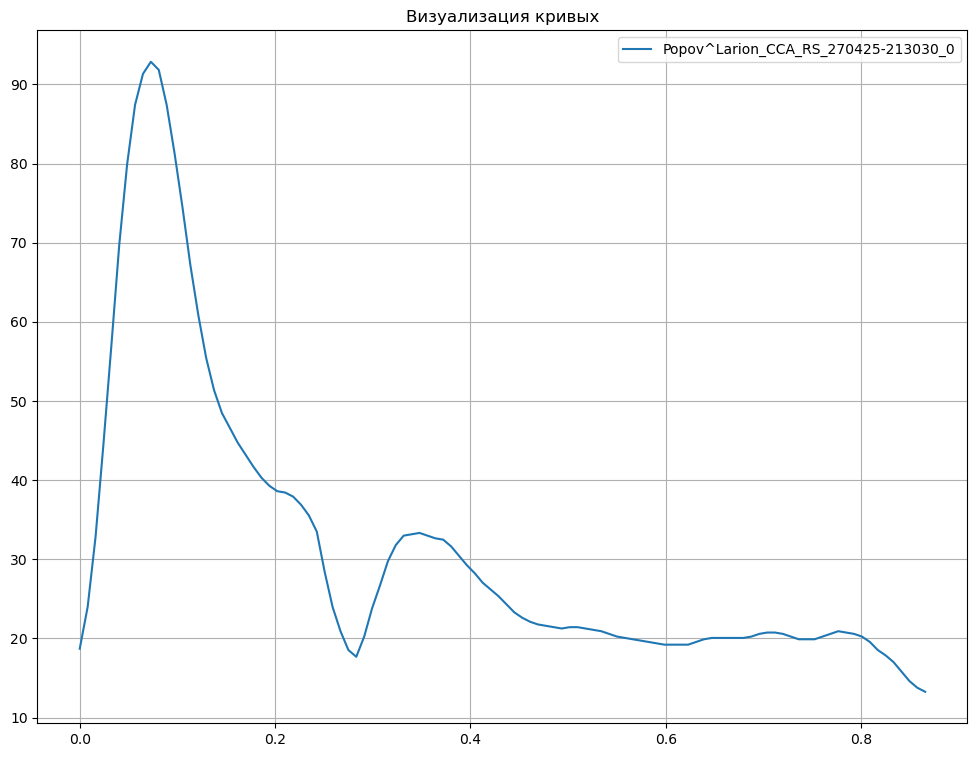

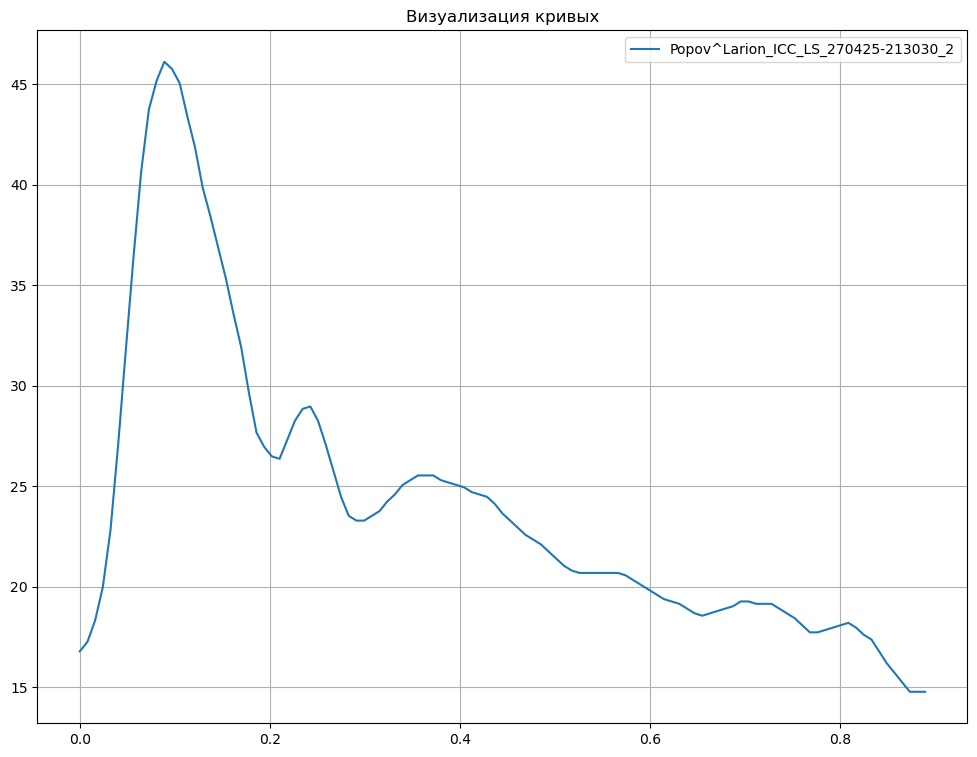

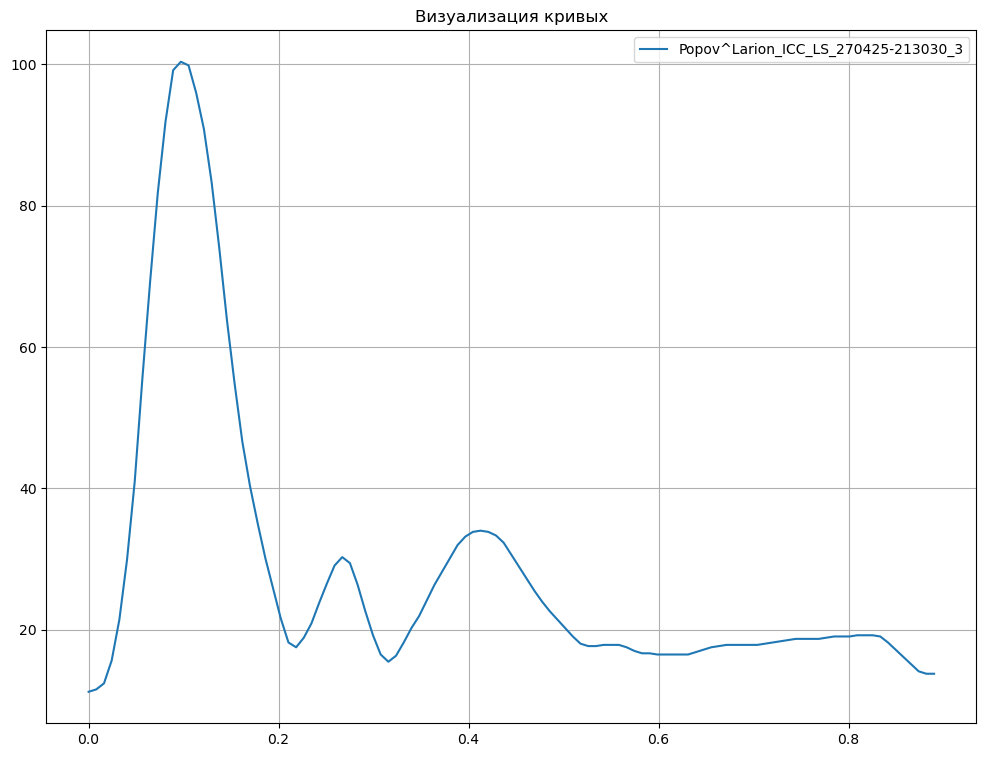

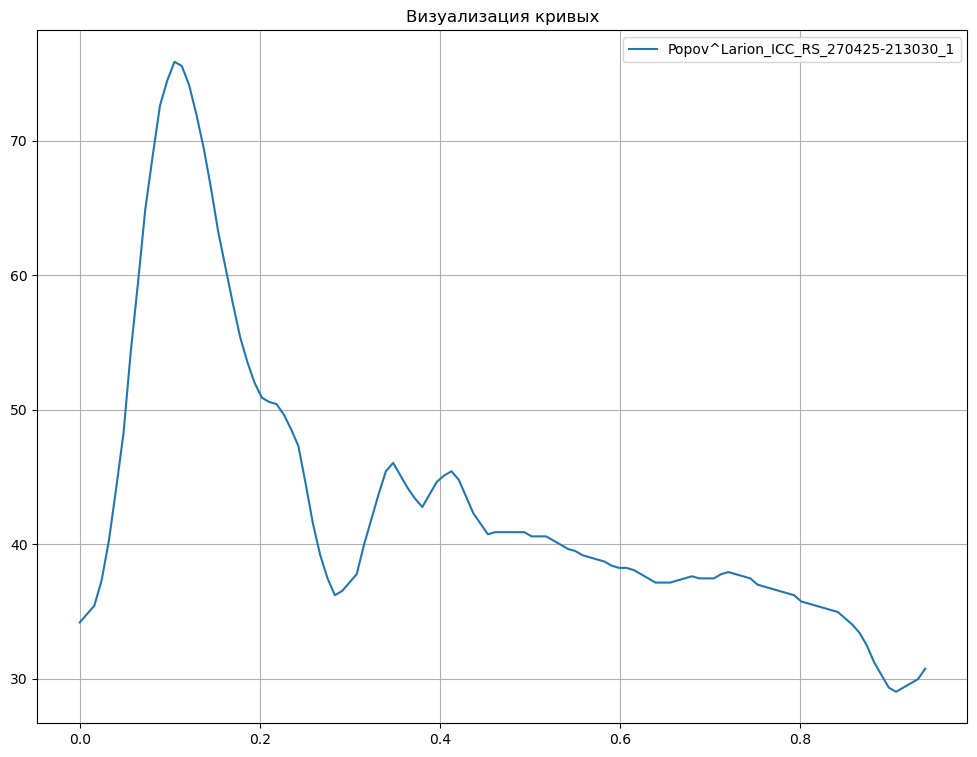

In [6]:
smooth_mappings = {}

for label, mapping in loader:
    smooth_mappings[label] = uniform_filter1d_for_mapping(mapping, 5)

    visualizator.create_plot([smooth_mappings[label].get_x()], [smooth_mappings[label].get_y()], [label])

### Кусочная аппроксимация сглажиного ряда

In [8]:
def run_pipeline(pipeline_loader:PipelineLoader):
    result = []
    for func, mapping, parametres, bounds in pipeline_loader:
        approx = search_most_viable_parametres(func, mapping, parametres, bounds)
        
        result.append(approx)

    return result

In [78]:
results_approx = {}

instructions = StructurePipelineApproximation(
    ['segment_1', 'segment_2', 'segment_3'],
    [lognormal_distribution for _ in range(3)],
    [[0, 0.35], [0.35, 0.65], [0.65, 1.5]],
    [(80, -1.9, 0.25, 10), (35, -0.8, 0.4, 5), (25, -0.29, 0.55, 2)],
    [([1, -3, 0.05, 0], [20, -0.5, 0.6, 30]), ([1, -1.5, 0.2, 0], [10, 0, 0.8, 20]), ([1, -1, 0.3, 0], [5, 0.5, 1.2, 10])]
)

for label, mapping in smooth_mappings.items():

    clear_mapping = preprocessing_pipeline(mapping)


    pipeline = PipelineLoader(clear_mapping, instructions)
    try:
        results_approx[label] = run_pipeline(pipeline)
    except:
        continue

`Визуализация результата`

In [13]:
def get_values_piecewise_approximation(results_approx:list):
    all_values = np.array([])

    for res in results_approx:
        all_values = np.r_[all_values, res.y_approx_denormalize]

    return all_values

def get_independent_values_sections(results_approx:list):
    all_values = np.array([])

    for res in results_approx:
        all_values = np.r_[all_values, res.mapping_start.get_x()]

    return all_values

def get_start_dependent_values(results_approx:list):
    all_values = np.array([])

    for res in results_approx:
        all_values = np.r_[all_values, res.mapping_start.get_y()]

    return all_values

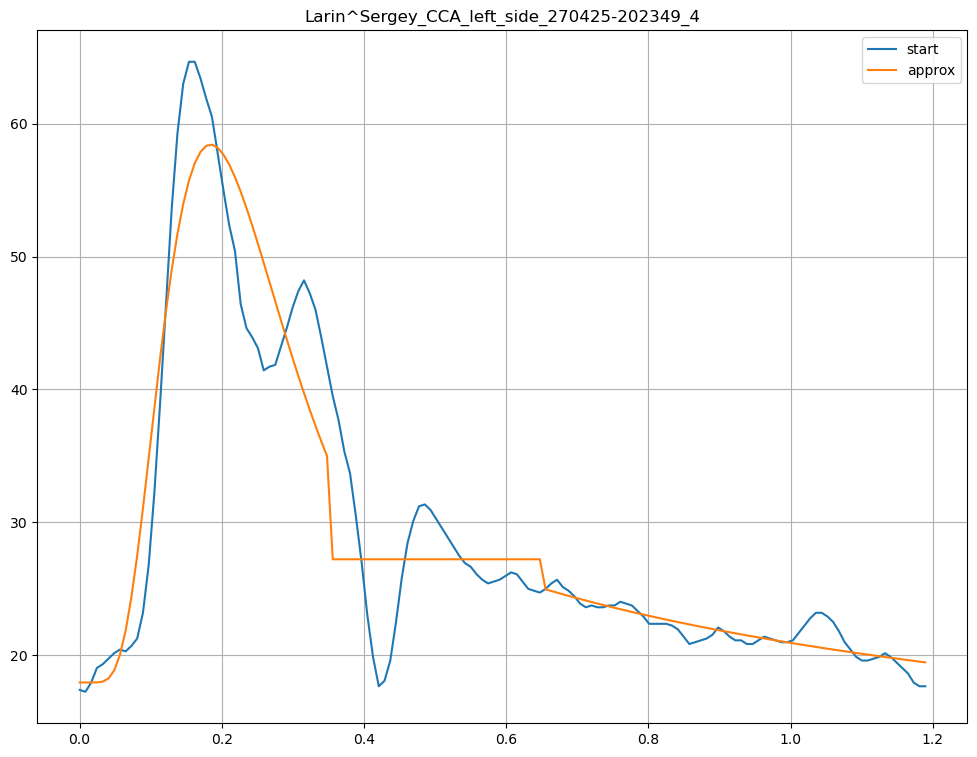

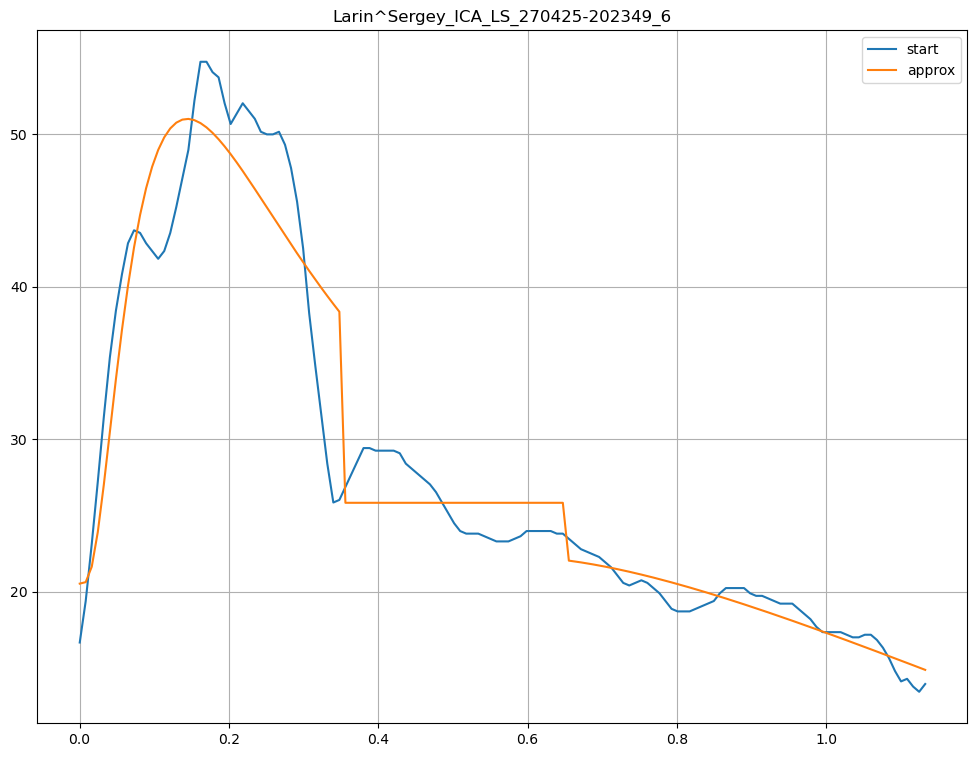

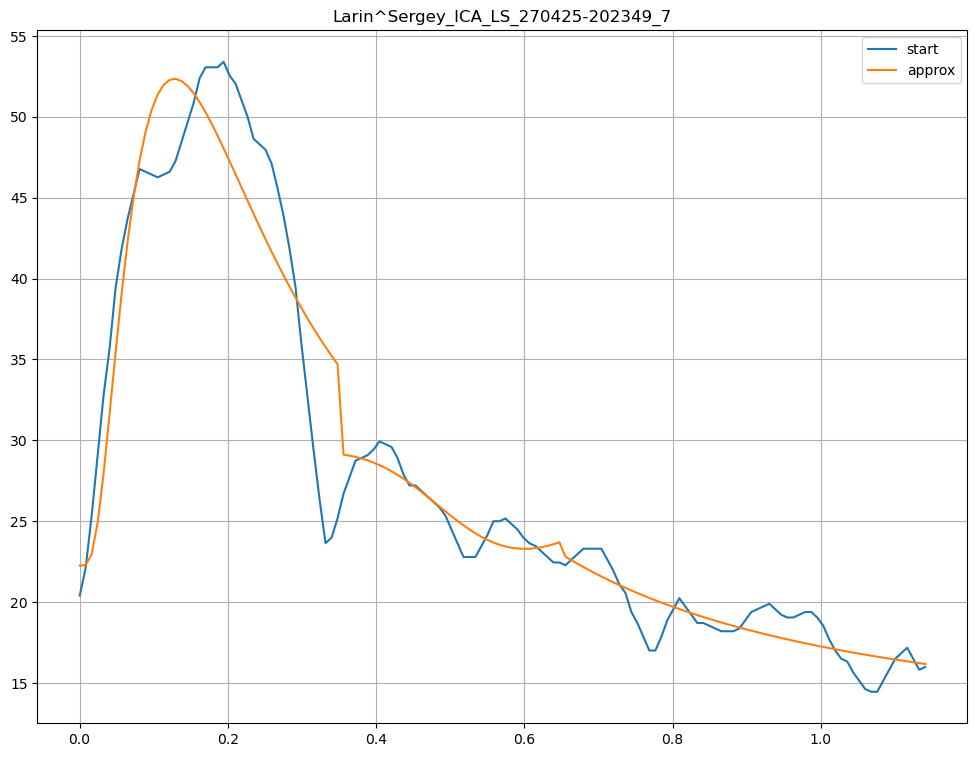

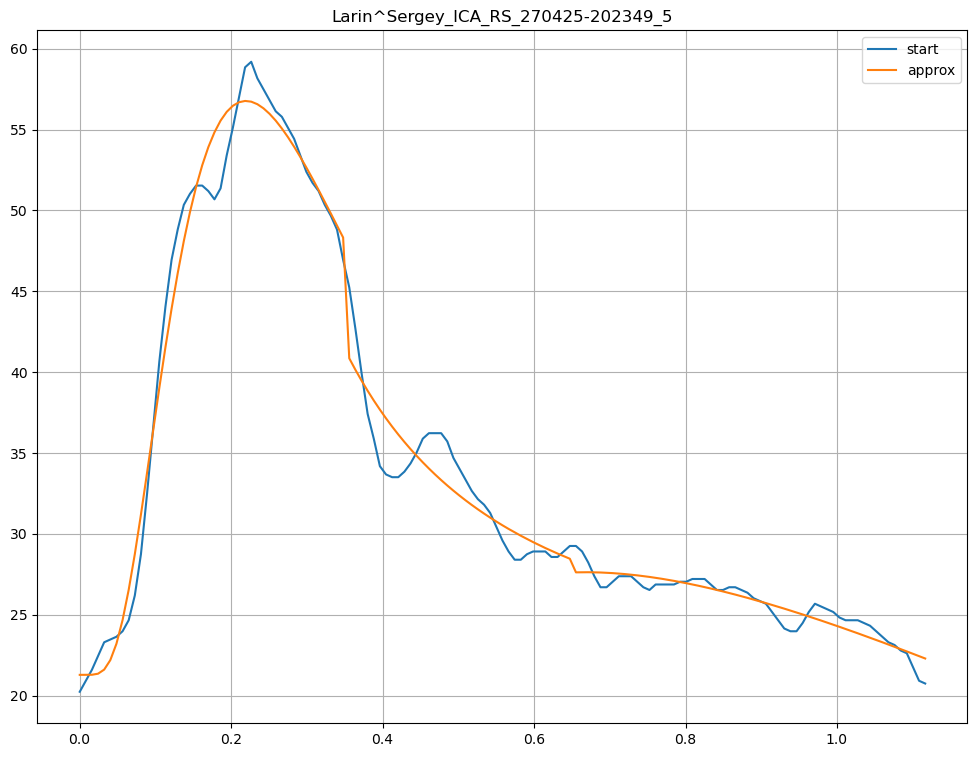

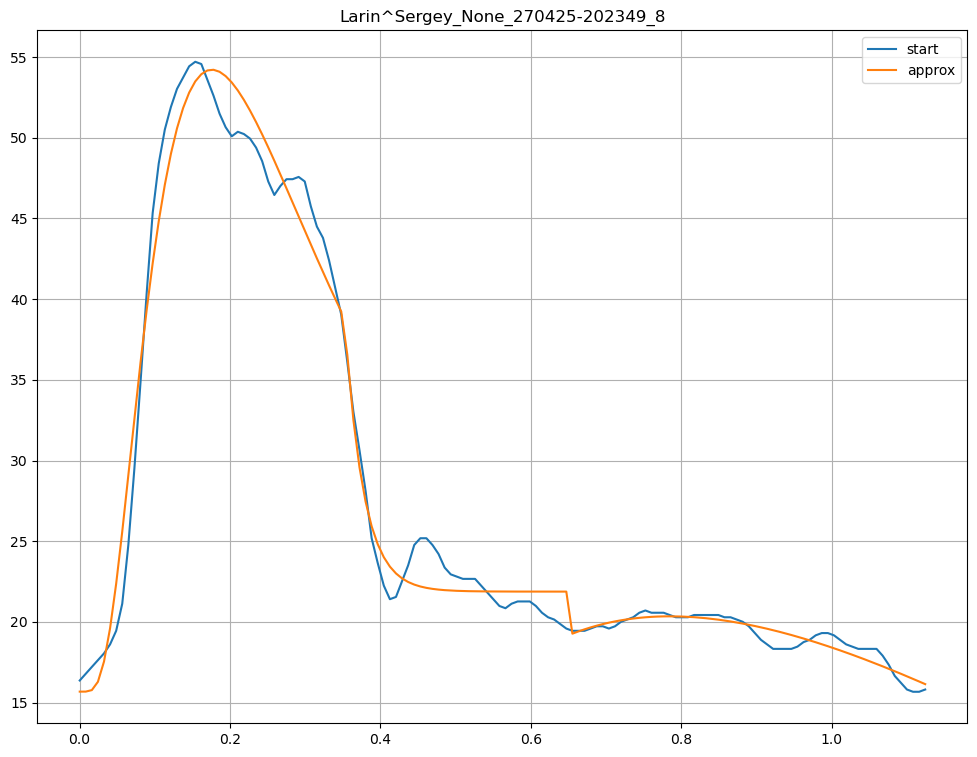

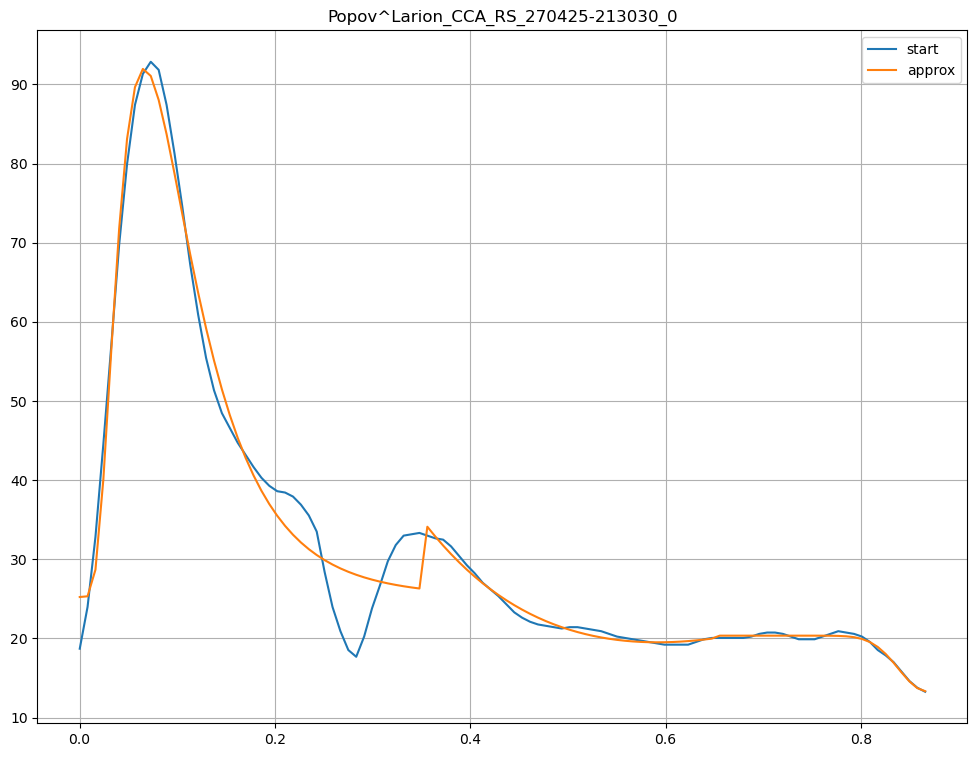

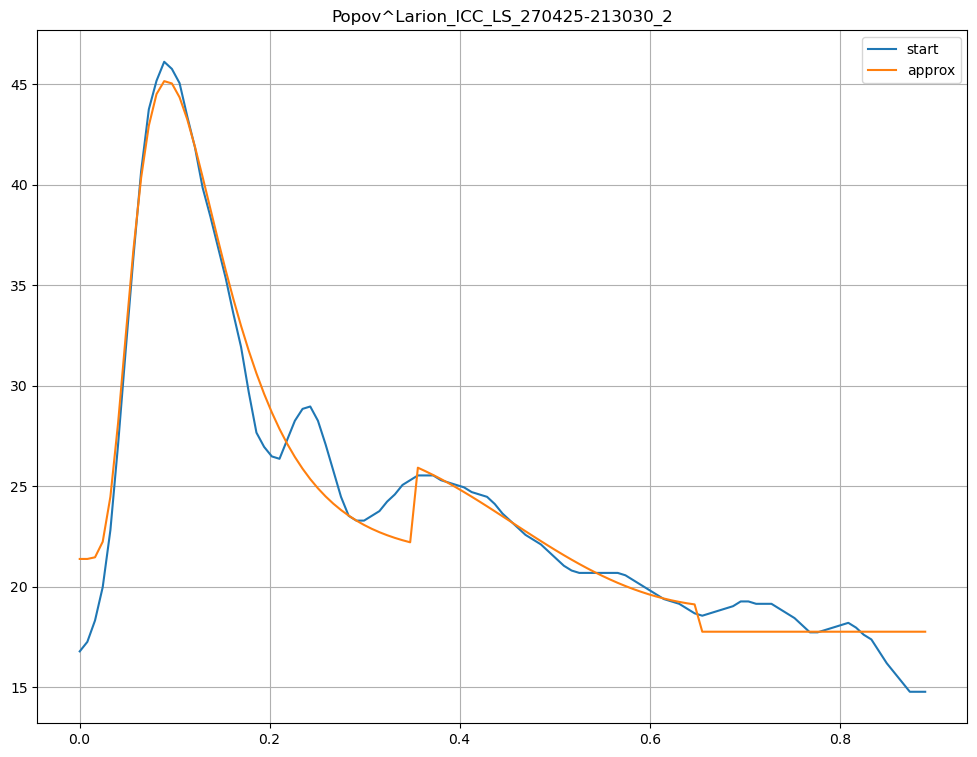

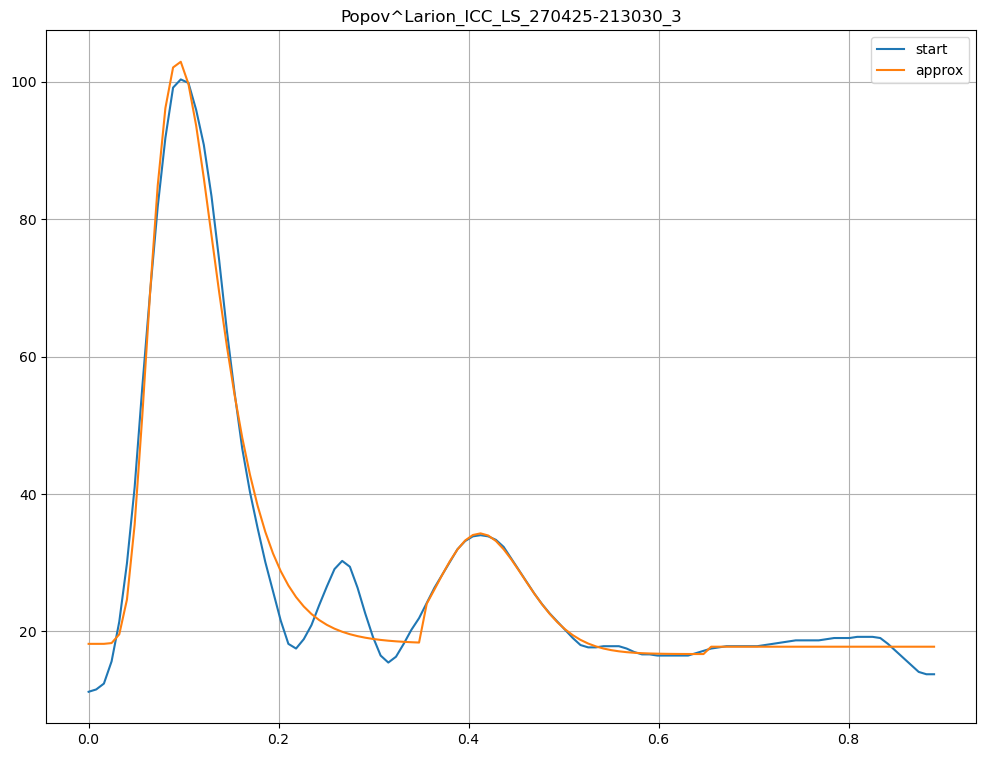

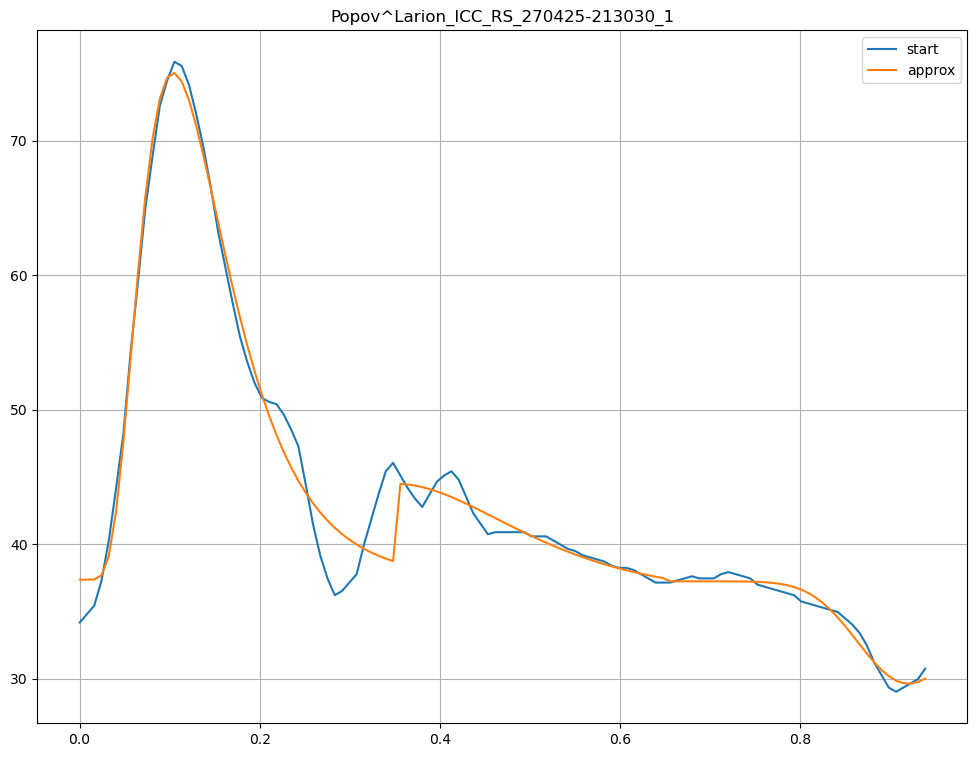

In [79]:
visualizator_result_approx = VisualizationPlots(
    (12, 9),
    'lognormal_distribution',
    True
)

for label, res in results_approx.items():
    visualizator_result_approx = VisualizationPlots(
        (12, 9),
        label,
        True
    )
    x = get_independent_values_sections(res)
    y_approx = get_values_piecewise_approximation(res)
    y_start = get_start_dependent_values(res)

    visualizator_result_approx.create_plot([x, x], [y_start, y_approx], ['start', 'approx'])

In [ ]:
funcs_metrics = {
    'MAE': mean_absolute_error,
    'MAPE': mean_absolute_percentage_error,
    'R^2': r2_score,
    'C_norm': max_error
}

for label, mappings in results_approx.items():
    file_path_coeffs = rf'C:\Users\obyde\OneDrive\Рабочий стол\results\lognormal_distribution\coeff_tables\{label}.xlsx'
    file_path_errors = rf'C:\Users\obyde\OneDrive\Рабочий стол\results\lognormal_distribution\errors\{label}.xlsx'
    errors = pd.DataFrame()
    coeffs = pd.DataFrame()

    for section in mappings:
        coeffs = pd.concat([coeffs, section.parametres_show()])
        errors = pd.concat([errors, section.metrix_values_show(funcs_metrics)])

    coeffs.to_excel(file_path_coeffs)
    errors.to_excel(file_path_errors)